# 01 - EELS modelling (nanopore)

We analyse an **EELS spectrum image** of a Si-N membrane containing a
nanopore: align it, strip the background, model the element edges and turn
those into elemental maps. At the end we fit the fine structure of the
Si-L edge with measured reference spectra.

**Prerequisite:** `00_setup_check.ipynb` ran without errors.

**Important:** the cells build on each other. Run them top to bottom
(menu *Run -> Run All Cells*, or cell by cell with `Shift+Enter`).

Documentation: <https://hyperspy.org/exspy/user_guide/eels.html>

In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


import matplotlib, matplotlib.pyplot as plt
print("backend    :", matplotlib.get_backend())
print("interactive:", plt.isinteractive())
print("figures    :", plt.get_fignums())

import hyperspy.api as hs
import exspy  # must be imported, otherwise HyperSpy does not know the EELS/EDX signal types


# Navigator and spectrum in ONE figure instead of two.
#
# signal.plot() on a spectrum image normally opens two separate figures - a
# navigator (the survey image you click on) and the signal (the spectrum). With
# %matplotlib widget, JupyterLab sometimes attaches only one of them to the cell
# output, and the one that goes missing is usually "Figure 2", the spectrum.
# As a single figure with two panels that cannot happen.
hs.preferences.Plot.use_subfigure = True

# Finds the data regardless of operating system (see workshop_data.py)
from workshop_data import load, load_standards

print("HyperSpy", hs.__version__, "| exspy", exspy.__version__)

backend    : module://matplotlib_inline.backend_inline
interactive: False
figures    : []


C:\Users\KoegelMarco\OneDrive - NMI\PycharmProjects\STEMDataAnalysisWorkshop\.pixi\envs\default\Lib\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
C:\Users\KoegelMarco\OneDrive - NMI\PycharmProjects\STEMDataAnalysisWorkshop\.pixi\envs\default\Lib\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


HyperSpy 2.4.0 | exspy 0.3.2


C:\Users\KoegelMarco\OneDrive - NMI\PycharmProjects\STEMDataAnalysisWorkshop\.pixi\envs\default\Lib\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


## 1. Load the data

`load()` finds the file inside `data/` by itself, which is why there is no
path here that only works on one particular machine.

- **high-loss**: the range holding the element edges (the actual signal)
- **low-loss**: the range around the zero-loss peak, needed for alignment

In [2]:
signal = load("eels_highloss", signal_type="EELS")
ll = load("eels_lowloss", signal_type="EELS")

signal

<EELSSpectrum, title: EELS Spectrum Image (high-loss), dimensions: (104, 70|2048)>

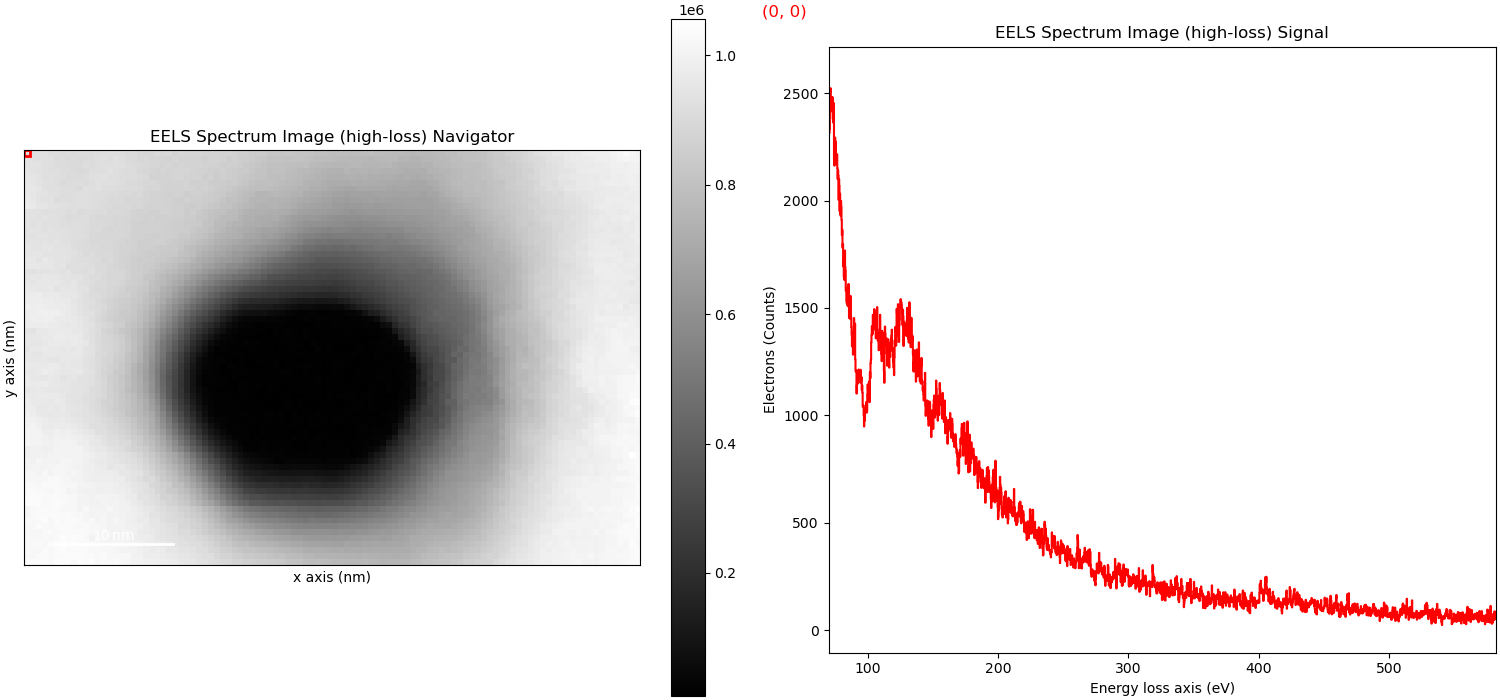

In [3]:
%matplotlib widget
hs.preferences.Plot.use_subfigure = True
signal.plot()

## 2. ADF survey image

The annular dark-field image shows where on the sample the data was taken.

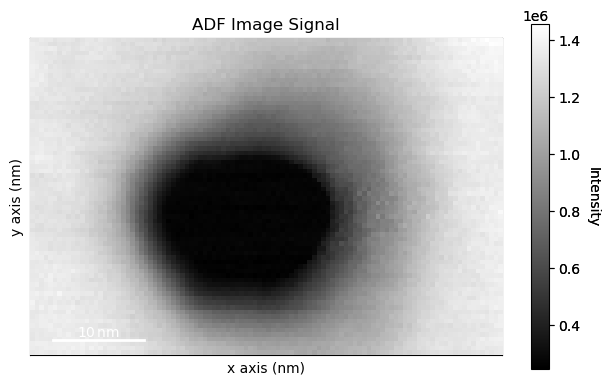

In [5]:
%matplotlib inline
adf_image = load("adf")
adf_image.plot()

## 3. Align the zero-loss peak

The energy axis drifts during acquisition. We measure the shift on the sharp
zero-loss peak in the low-loss spectrum and apply the same correction to the
high-loss spectrum (`also_align`).

Without this step the edges sit at slightly wrong energies and the model is
systematically off.

In [6]:
ll.align_zero_loss_peak(also_align=[signal], signal_range=(-10.0, 10.0))

Initial ZLP position statistics
-------------------------------
Summary statistics
------------------
mean:	-0.525
std:	0.138

min:	-0.75
Q1:	-0.5
median:	-0.5
Q3:	-0.5
max:	-0.25


  0%|          | 0/232 [00:00<?, ?it/s]

  0%|          | 0/232 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/232 [00:00<?, ?it/s]

  0%|          | 0/232 [00:00<?, ?it/s]

## 4. Build the EELS model

Three steps:

1. **Declare the elements** - exspy then creates one model component per edge
2. **Binning** (`rebin`) - merges 2x2 pixels. Less spatial resolution, but a
   better signal-to-noise ratio and a much faster fit.
3. **Strip the background** - the power law in front of the first edge (70-96 eV)

The very first call to `create_model()` downloads the GOSH database
(~42 MB) once and caches it permanently.

In [7]:
signal.add_elements(["Si", "O", "N"])

signal_binned = signal.rebin(scale=[2, 2, 1])
signal_binned = signal_binned.remove_background(signal_range=(70.0, 96.0))

m = signal_binned.create_model(auto_background=False)
m.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |               Si_L3 |               Si_L3 |          EELSCLEdge
   1 |               Si_L2 |               Si_L2 |          EELSCLEdge
   2 |               Si_L1 |               Si_L1 |          EELSCLEdge
   3 |                 O_K |                 O_K |          EELSCLEdge
   4 |                 N_K |                 N_K |          EELSCLEdge

### Inspect the model - interactively **or** in code

Both cells show the same thing. Use whichever works for you.

**Variant A is switched off by default, on purpose.** An open `m.gui()` widget
binds every model parameter to a slider, and a fit cannot run while that binding
is live - it dies with `TraitError: Broken link`. Variant B has no such problem
and is what the notebook uses when you run all cells.

In [8]:
# --- Variant A: interactive ---
#
# CAUTION: leave this widget CLOSED while fitting.
#
# m.gui() links every model parameter to a slider (hyperspy_gui_ipywidgets
# builds that link in model.py). During multifit the optimiser writes each
# parameter thousands of times per second; every value travels to the browser
# and comes back with float32 precision, so it differs in the eighth digit.
# link_traits sees the source change while it is updating the target and stops
# the fit with:
#
#   TraitError: Broken link ...: the source value changed while updating the target
#
# The cell is therefore off by default. If you switch it on and then want to
# fit, re-run the cell above that creates the model first - a fresh model has
# no widget attached to it.

SHOW_GUI = False

if SHOW_GUI:
    m.gui()
else:
    print("interactive widget off - set SHOW_GUI = True to open it.")
    print("Re-run the model-creation cell before fitting if you do.")

Accordion(children=(VBox(children=(Checkbox(value=True, description='active'), Checkbox(value=False, descripti…

In [10]:
# --- Variant B: same thing in code, always works ---
for component in m:
    print(f"{component.name}   active={component.active}")
    for p in component.parameters:
        print(f"    {p.name:12s} value={p.value!s:12s} free={p.free}")

Si_L3   active=True
    intensity    value=1.001091     free=True
    fine_structure_coeff value=(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)) free=False
    effective_angle value=111.1        free=False
    onset_energy value=99.15        free=False
Si_L2   active=True
    intensity    value=1.001091     free=False
    fine_structure_coeff value=(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int

In [11]:
%matplotlib qt
m.plot()

## 5. Fitting

`multifit` fits every pixel separately. `kind="smart"` is the EELS variant:
it fits the background in front of each edge first and then the edge itself,
which is far more stable than fitting the whole range in one go.

Depending on the size of the dataset this can take several minutes.

In [12]:
m.multifit(kind="smart")

100%|██████████| 1820/1820 [03:34<00:00,  8.50it/s]


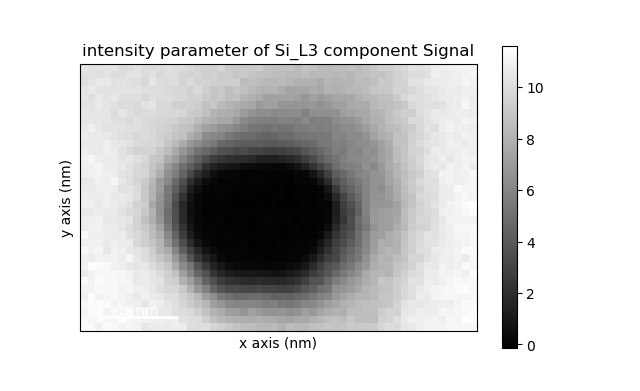

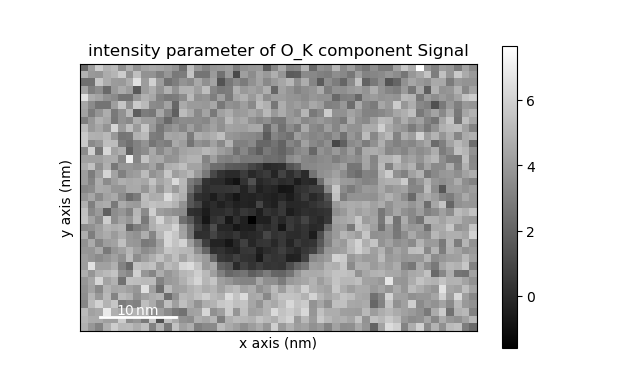

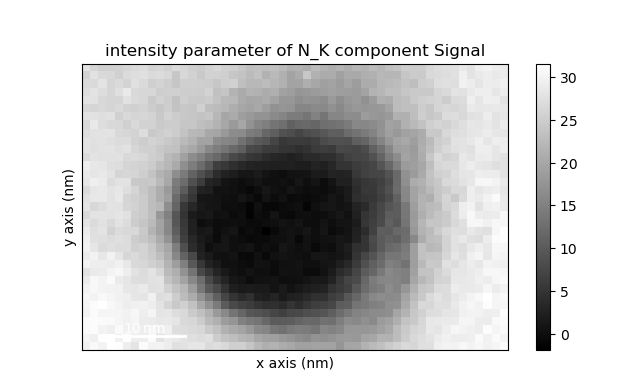

In [11]:
%matplotlib widget
m.plot_results()

## 6. Fine structure of the Si-L edge with reference spectra

The shape just past the edge (ELNES) depends on chemical bonding - Si in SiO2
looks different from Si in Si3N4. Instead of modelling the edge physically we
fit a **linear combination of measured reference spectra** here.

Each reference becomes a `ScalableFixedPattern`: a fixed curve shape whose
height (`yscale`) is fitted freely while stretch (`xscale`) and shift
(`shift`) are held fixed. The fitted `yscale` is then the share of that
bonding type in the given pixel.

In [ ]:
# Prepare the region around the Si-L edge and smooth it slightly.
#
# Note: the original notebook started with signal.isig[:280.], which the very
# next line overwrote, so it had no effect at all. This is the intended order -
# bin, strip the background, then crop.
signal_binned = signal.rebin(scale=[2, 2, 1])
signal_binned = signal_binned.remove_background(signal_range=(70.0, 96.0))
signal_binned = signal_binned.isig[92.0:170.0]

s_smooth = signal_binned.deepcopy()
s_smooth.data = gaussian_filter1d(s_smooth.data, sigma=2, axis=-1)
s_smooth.plot()

In [ ]:
# Load the references, normalise them to a maximum of 1 and smooth them by the
# same amount as the data - otherwise you compare differently blurred curves.
standards = load_standards("si_standards", sigma=2)

for name, s in standards.items():
    s.data = s.data / s.data.max()
    print(name)

In [ ]:
m = s_smooth.create_model(auto_background=False)

for name, s in standards.items():
    pattern = hs.model.components1D.ScalableFixedPattern(s)
    pattern.name = name

    pattern.xscale.free = False   # do not stretch or squeeze the energy axis
    pattern.shift.free = False    # and do not shift it
    pattern.yscale.bmin = 0       # negative shares make no physical sense
    pattern.yscale.bmax = 1e7

    m.append(pattern)

m.components

In [ ]:
# --- Variant A: interactive ---
#
# CAUTION: leave this widget CLOSED while fitting.
#
# m.gui() links every model parameter to a slider (hyperspy_gui_ipywidgets
# builds that link in model.py). During multifit the optimiser writes each
# parameter thousands of times per second; every value travels to the browser
# and comes back with float32 precision, so it differs in the eighth digit.
# link_traits sees the source change while it is updating the target and stops
# the fit with:
#
#   TraitError: Broken link ...: the source value changed while updating the target
#
# The cell is therefore off by default. If you switch it on and then want to
# fit, re-run the cell above that creates the model first - a fresh model has
# no widget attached to it.

SHOW_GUI = False

if SHOW_GUI:
    m.gui()
else:
    print("interactive widget off - set SHOW_GUI = True to open it.")
    print("Re-run the model-creation cell before fitting if you do.")

In [ ]:
# --- Variant B: same thing in code ---
# The model holds two kinds of component: the edge components (EELSCLEdge)
# created by add_elements, and our reference patterns. Only the latter have
# a yscale, so ask before reading it.
for component in m:
    yscale = getattr(component, "yscale", None)
    if yscale is None:
        print(f"{component.name:20s} (edge model, no yscale)")
    else:
        print(f"{component.name:20s} yscale={yscale.value}")

In [ ]:
m.plot()

In [ ]:
# bounded=True so that the bmin/bmax limits set above are actually respected
m.multifit(bounded=True)

In [ ]:
m.plot_results()

## Exercises

1. Run section 4 without the `rebin` step. How do runtime and noise in the
   elemental maps change?
2. Move the background window in `remove_background` from `(70, 96)` to
   `(60, 90)`. How much do the edge intensities change?
3. In section 6, also let `shift` float (`pattern.shift.free = True`). Does the
   fit improve, or does it start compensating for nonsense?